<a href="https://colab.research.google.com/github/ParushiSrivastava/PARUSHI.23FE10CSE00380/blob/main/lab_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.model_selection import GridSearchCV


In [ ]:
cancer = load_breast_cancer()

# View dictionary keys
print(cancer.keys())

# Feature names
print("\nFeature Names:")
print(cancer.feature_names)

# Create DataFrame
df = pd.DataFrame(
    data=cancer.data,
    columns=cancer.feature_names
)

# Add target column
df['target'] = cancer.target

# Dataset description
print("\nDataset Info:")
print(df.info())

print("\nDataset Description:")
print(df.describe())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())


dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

Feature Names:
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-n

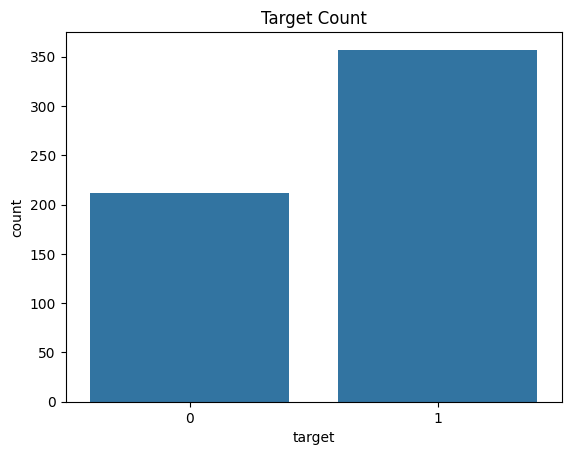

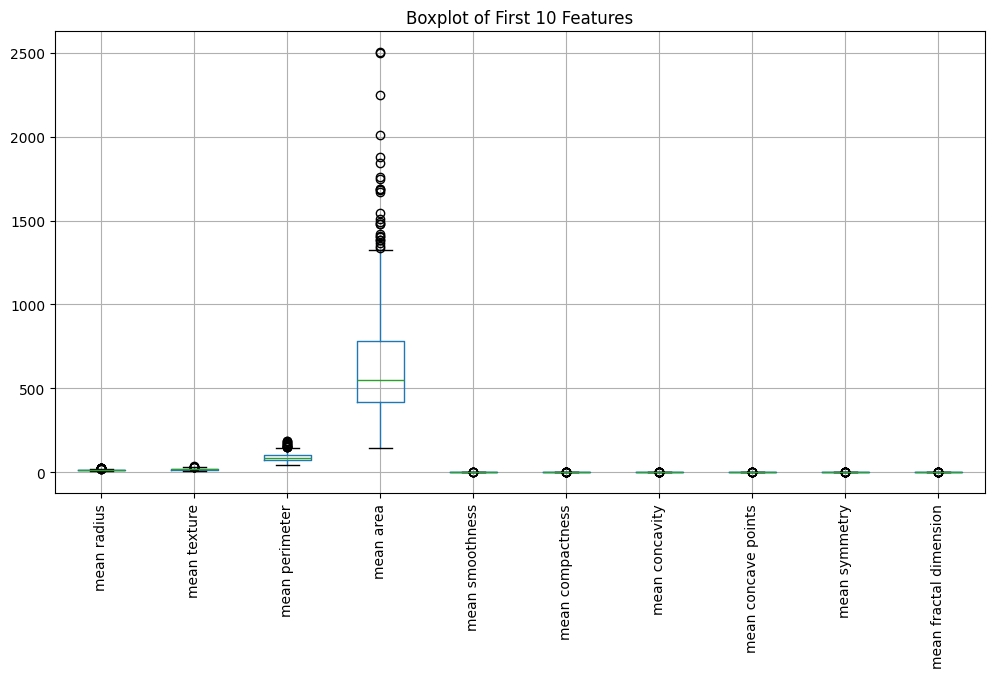

In [ ]:
sns.countplot(x='target', data=df)
plt.title("Target Count")
plt.show()

# Boxplot for first 10 columns
plt.figure(figsize=(12,6))

df.iloc[:, 0:10].boxplot()

plt.xticks(rotation=90)
plt.title("Boxplot of First 10 Features")
plt.show()


In [ ]:

# Features (drop target column)
X = df.drop('target', axis=1)

# Target
y = df['target']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [ ]:
model = SVC()

model.fit(X_train, y_train)

SVC()

In [ ]:
predictions = model.predict(X_test)

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, predictions))


Confusion Matrix:
[[37  6]
 [ 0 71]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.86      0.93        43
           1       0.92      1.00      0.96        71

    accuracy                           0.95       114
   macro avg       0.96      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114



In [ ]:
param_grid = {
    'C': [0.1, 1, 10, 100, 1000],
    'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
    'kernel': ['rbf']
}

grid = GridSearchCV(
    SVC(),
    param_grid,
    refit=True,
    verbose=3
)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.637 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.626 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.626 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.626 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.626 total time=   0.0s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.637 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.626 total time=   0.0s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.626 total time=   0.0s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.626 total time=   0.0s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.626 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.637 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf']},
             verbose=3)

In [ ]:
# Best Parameters
print("\nBest Parameters:")
print(grid.best_params_)

# Predict using GridSearch model
grid_predictions = grid.predict(X_test)

# Confusion Matrix
print("\nConfusion Matrix After GridSearch:")
print(confusion_matrix(y_test, grid_predictions))

# Classification Report
print("\nClassification Report After GridSearch:")
print(classification_report(y_test, grid_predictions))


Best Parameters:
{'C': 10, 'gamma': 0.0001, 'kernel': 'rbf'}

Confusion Matrix After GridSearch:
[[39  4]
 [ 2 69]]

Classification Report After GridSearch:
              precision    recall  f1-score   support

           0       0.95      0.91      0.93        43
           1       0.95      0.97      0.96        71

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114

